<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/Lasso_regression_ml_day_56.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [3]:
X,y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

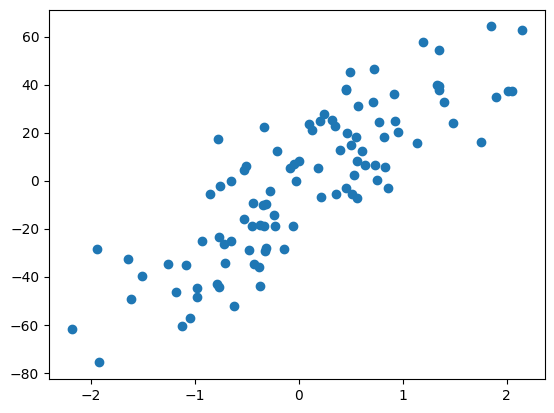

In [5]:
plt.scatter(X,y)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
lr=LinearRegression()
lr.fit(X_train,y_train)
print('coef_value',lr.coef_)
print('intercept_value',lr.intercept_)

coef_value [25.63578704]
intercept_value -0.5980951387463362


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.093e+04, tolerance: 6.614e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

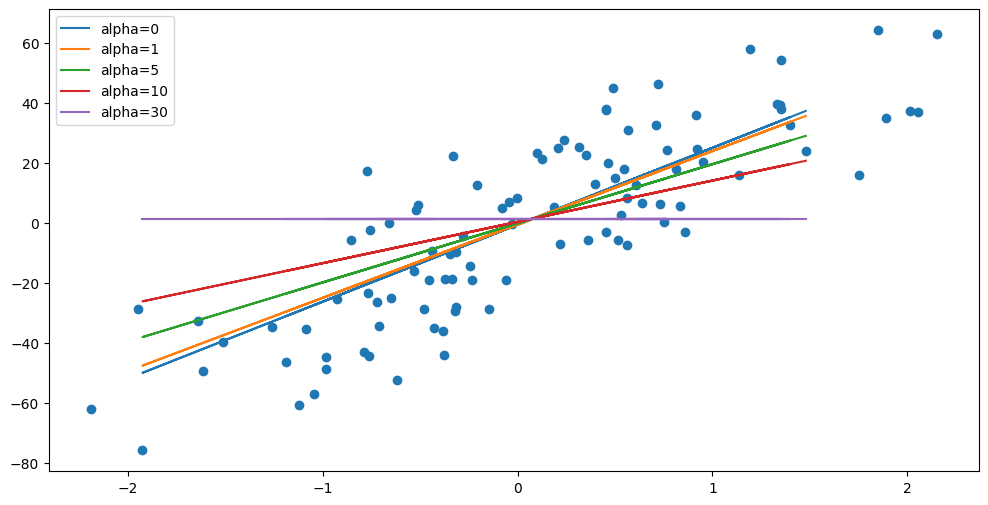

In [9]:
alphas=[0,1,5,10,30]
plt.figure(figsize=(12,6))
plt.scatter(X,y)

for i in alphas:
  l=Lasso(alpha=i)
  l.fit(X_train,y_train)
  plt.plot(X_test,l.predict(X_test),label='alpha={}'.format(i))

plt.legend()
plt.show()

In [15]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

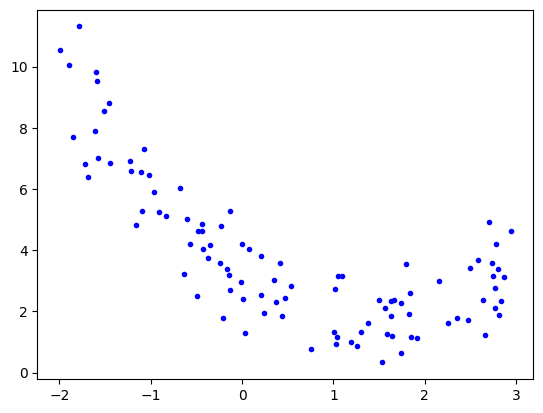

In [19]:
plt.plot(x1,x2,'b.')

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.630e+01, tolerance: 5.896e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

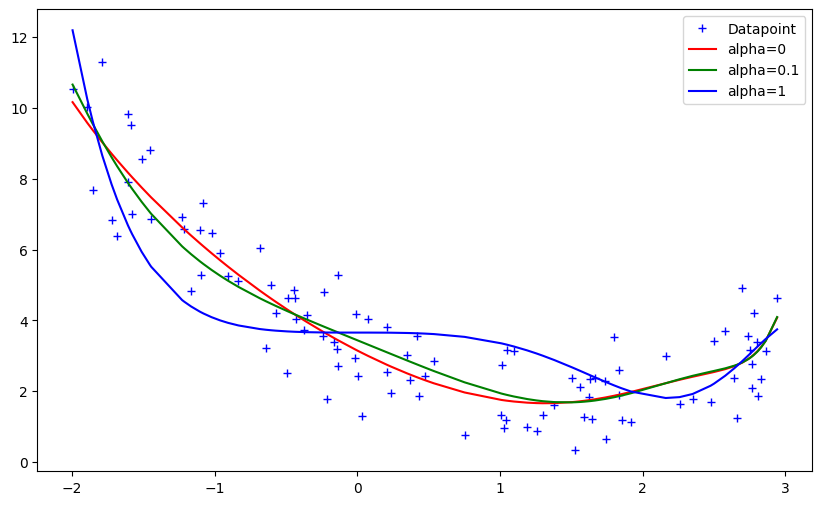

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_preds_lasso(x1,x2,alpha):
  model=Pipeline([
      ('poly_feats',PolynomialFeatures(degree=16)),
      ('lassso',Lasso(alpha=alpha))
        ])

  model.fit(x1,x2)
  return model.predict(x1)

alphas=[0,0.1,1]
cs=['r','g','b']

plt.figure(figsize=(10,6))
plt.plot(x1,x2,'b+',label='Datapoint')

for alpha, c in zip(alphas,cs):
  preds=get_preds_lasso(x1,x2,alpha)
  plt.plot(sorted(x1[ :,0]),preds[np.argsort(x1[:,0])],c,label='alpha={}'.format(alpha))


plt.legend ()
plt.show()

